In [1]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\leila.gh\Desktop\selfsteem.socialcomparison\selfsteem.xlsx"

# اگر شیت Results وجود داشت از آن بخوان، وگرنه شیت اول را بخوان
try:
    df = pd.read_excel(file_path, sheet_name="Results")
except ValueError:
    df = pd.read_excel(file_path, sheet_name=0)

# حذف ردیف‌های کاملاً خالی
df = df.dropna(how='all')

# فقط ردیف‌هایی که شناسه پاسخ‌دهنده دارند
df = df[df.iloc[:, 1].notna()].reset_index(drop=True)

print("ابعاد داده:", df.shape)
df.head()

ابعاد داده: (135, 55)


,پاسخنامه,شناسه پاسخ دهنده,جنسیت شما کدام است؟,عدد سن خود را وارد نمایید.,تحصیلات خود را انتخاب نمایید.,1.اگر برای عزیزانم یا دوستانم کاری انجام میدهم، آن را با کارهایی که دیگران انجام میدهند مقایسه میکنم.,2. به روشی که خودم کارها را انجام می دهم نسبت به روشی که سایرین انجام می دهند، توجه زیادی دارم.,3. عملکرد خودم را با دیگران مقایسه می کنم.,4. معمولاً رفتارها و مهارت های اجتماعی خودم را با این قبیل مهارت ها در دیگران مقایسه می کنم.,5. از آن دسته افرادی نیستم که خودش را با دیگران مقایسه می کند.,...,3. میتوانم به خوبی اکثر مردم، کارها را انجام بدهم.,4. نسبت به خود نگرش مثبت دارم.,5. به طور کلی از خودم راضی هستم.,6. احساس میکنم چیز زیادی ندارم که به آن ها افتخار کنم.,7. با در نظر گرفتن همه چیز معمولا فکر میکنم که شکست خورده ام.,8. ای کاش میتوانستم احترام بیشتری برای خودم قائل بشوم.,9. گاهی احساس میکنم بی فایده هستم.,10. گاهی فکر میکنم اصلا نمیتوانم کاری انجام بدهم.,تاریخ شروع,تاریخ اتمام
0,https://survey.porsline.ir/n/k/fV8lzoJ7/2Sfku?...,2Sfku,زن,۲۲,لیسانس و فوق لیسانس,تا حدی موافقم,تاحدی مخالفم,نظری ندارم,تا حدی موافقم,نظری ندارم,...,موافق,موافق,موافق,موافق,موافق,موافق,موافق,موافق,1404/02/18-00:01:27,1404/02/18-00:03:08
1,https://survey.porsline.ir/n/k/fV8lzoJ7/Dg0yk?...,Dg0yk,زن,21,دیپلم و فوق دیپلم,موافقم,موافقم,تا حدی موافقم,موافقم,مخالفم,...,موافق,موافق,موافق,مخالف,مخالف,مخالف,موافق,موافق,1404/02/17-16:55:01,1404/02/17-16:59:16
2,https://survey.porsline.ir/n/k/fV8lzoJ7/zAy6T?...,zAy6T,زن,19,دیپلم و فوق دیپلم,موافقم,خیلی موافقم,خیلی موافقم,خیلی موافقم,خیلی مخالفم,...,موافق,موافق,مخالف,موافق,موافق,موافق,موافق,موافق,1404/02/17-15:35:04,1404/02/17-16:03:12
3,https://survey.porsline.ir/n/k/fV8lzoJ7/K2mXc?...,K2mXc,زن,۳۵,لیسانس و فوق لیسانس,مخالفم,تاحدی مخالفم,مخالفم,مخالفم,موافقم,...,موافق,مخالف,مخالف,موافق,موافق,مخالف,موافق,موافق,1404/02/17-15:50:43,1404/02/17-15:56:17
4,https://survey.porsline.ir/n/k/fV8lzoJ7/bol28?...,bol28,زن,32,لیسانس و فوق لیسانس,تا حدی موافقم,تا حدی موافقم,تا حدی موافقم,تا حدی موافقم,موافقم,...,موافق,موافق,موافق,مخالف,مخالف,مخالف,مخالف,مخالف,1404/02/17-12:21:02,1404/02/17-12:27:55


In [2]:
def fa_to_en_digits(x):
    if pd.isna(x):
        return x
    return str(x).translate(str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789'))

# ستون سن
age_col = df.columns[3]
df[age_col] = pd.to_numeric(df[age_col].apply(fa_to_en_digits), errors='coerce')

# نام‌گذاری ستون‌های جمعیت‌شناختی
df = df.rename(columns={
    df.columns[2]: 'Gender',
    df.columns[3]: 'Age',
    df.columns[4]: 'Education'
})

# حذف سن‌های غیرواقعی
df.loc[(df['Age'] < 15) | (df['Age'] > 80), 'Age'] = np.nan

df[['Gender', 'Age', 'Education']].head()

,Gender,Age,Education
0,زن,22.0,لیسانس و فوق لیسانس
1,زن,21.0,دیپلم و فوق دیپلم
2,زن,19.0,دیپلم و فوق دیپلم
3,زن,35.0,لیسانس و فوق لیسانس
4,زن,32.0,لیسانس و فوق لیسانس


In [3]:
# بر اساس جایگاه ستون‌ها در فایل
sc_cols = df.columns[5:16].tolist()      # مقایسه اجتماعی: ۱۱ سوال
mid_cols = df.columns[16:43].tolist()    # مقیاس میانی: ۲۷ سوال
se_cols = df.columns[43:53].tolist()     # عزت نفس: ۱۰ سوال

print("مقایسه اجتماعی:", len(sc_cols))
print("مقیاس میانی:", len(mid_cols))
print("عزت نفس:", len(se_cols))

مقایسه اجتماعی: 11
مقیاس میانی: 27
عزت نفس: 10


In [4]:
likert_map = {
    'خیلی مخالفم': 1,
    'مخالفم': 2,
    'تا حدودی مخالفم': 3,
    'تاحدی مخالفم': 3,
    'تا حدی مخالفم': 3,
    'نظری ندارم': 4,
    'تا حدی موافقم': 5,
    'تاحدی موافقم': 5,
    'موافقم': 6,
    'خیلی موافقم': 7
}

def likert_to_num(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().replace('ي', 'ی').replace('ك', 'ک')
    x = ' '.join(x.split())
    return likert_map.get(x, np.nan)

for c in sc_cols + mid_cols + se_cols:
    df[c] = df[c].apply(likert_to_num)

# بررسی مقادیر نامعتبر
print("تعداد مقادیر نامعتبر در مقایسه اجتماعی:", df[sc_cols].isna().sum().sum())
print("تعداد مقادیر نامعتبر در مقیاس میانی:", df[mid_cols].isna().sum().sum())
print("تعداد مقادیر نامعتبر در عزت نفس:", df[se_cols].isna().sum().sum())

تعداد مقادیر نامعتبر در مقایسه اجتماعی: 0
تعداد مقادیر نامعتبر در مقیاس میانی: 0
تعداد مقادیر نامعتبر در عزت نفس: 1350


In [5]:
def reverse_7(x):
    return 8 - x if pd.notna(x) else np.nan

# سوالات معکوس مقایسه اجتماعی: سوال ۵ و ۱۱
sc_reverse_idx = [4, 10]

# سوالات معکوس مقیاس میانی: این را بر اساس دفترچه مقیاس تنظیم کن
mid_reverse_idx = [1, 2, 4, 5, 7, 8, 10, 11, 12, 13, 14, 15, 16, 18, 20, 21, 22, 23, 25]

# سوالات معکوس عزت نفس: سوال ۶ تا ۱۰
se_reverse_idx = [5, 6, 7, 8, 9]

for i in sc_reverse_idx:
    df[sc_cols[i]] = df[sc_cols[i]].apply(reverse_7)

for i in mid_reverse_idx:
    df[mid_cols[i]] = df[mid_cols[i]].apply(reverse_7)

for i in se_reverse_idx:
    df[se_cols[i]] = df[se_cols[i]].apply(reverse_7)

In [6]:
df['SC_mean'] = df[sc_cols].mean(axis=1)
df['MID_mean'] = df[mid_cols].mean(axis=1)
df['SE_mean'] = df[se_cols].mean(axis=1)

df['SC_sum'] = df[sc_cols].sum(axis=1)
df['MID_sum'] = df[mid_cols].sum(axis=1)
df['SE_sum'] = df[se_cols].sum(axis=1)

df[['SC_mean', 'MID_mean', 'SE_mean']].describe()

,SC_mean,MID_mean,SE_mean
count,135.000000,135.000000,0.0
mean,4.901010,4.610151,NaN
std,0.980220,0.954687,NaN
min,2.363636,2.518519,NaN
25%,4.181818,4.000000,NaN
50%,5.000000,4.629630,NaN
75%,5.636364,5.333333,NaN
max,6.909091,6.407407,NaN


In [7]:
def cronbach_alpha(items_df):
    items_df = items_df.dropna()
    k = items_df.shape[1]
    if k < 2:
        return np.nan
    item_var = items_df.var(axis=0, ddof=1)
    total_var = items_df.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

print("آلفای کرونباخ مقایسه اجتماعی:", cronbach_alpha(df[sc_cols]))
print("آلفای کرونباخ مقیاس میانی:", cronbach_alpha(df[mid_cols]))
print("آلفای کرونباخ عزت نفس:", cronbach_alpha(df[se_cols]))

آلفای کرونباخ مقایسه اجتماعی: 0.8323720161509656
آلفای کرونباخ مقیاس میانی: 0.894980624888931
آلفای کرونباخ عزت نفس: nan


In [8]:
print(df.groupby('Gender')[['SC_mean', 'MID_mean', 'SE_mean']].agg(['mean', 'std', 'count']))

print(df.groupby('Education')[['SC_mean', 'MID_mean', 'SE_mean']].agg(['mean', 'std', 'count']))

         SC_mean                  MID_mean                 SE_mean          
            mean       std count      mean       std count    mean std count
Gender                                                                      
زن      5.045005  0.918373   101  4.511918  0.923900   101     NaN NaN     0
مرد     4.473262  1.045851    34  4.901961  0.998518    34     NaN NaN     0
                      SC_mean                  MID_mean                  \
                         mean       std count      mean       std count   
Education                                                                 
دکترا و فوق دکترا    5.238636  0.733637     8  4.652778  1.011387     8   
دیپلم و فوق دیپلم    5.181818  0.959828    20  4.501852  1.026504    20   
لیسانس و فوق لیسانس  4.823280  0.992159   107  4.627207  0.945047   107   

                    SE_mean            
                       mean std count  
Education                              
دکترا و فوق دکترا       NaN NaN     0  
دیپل

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

           SC_mean  MID_mean  SE_mean       Age
SC_mean   1.000000 -0.504102      NaN -0.391379
MID_mean -0.504102  1.000000      NaN  0.390299
SE_mean        NaN       NaN      NaN       NaN
Age      -0.391379  0.390299      NaN  1.000000


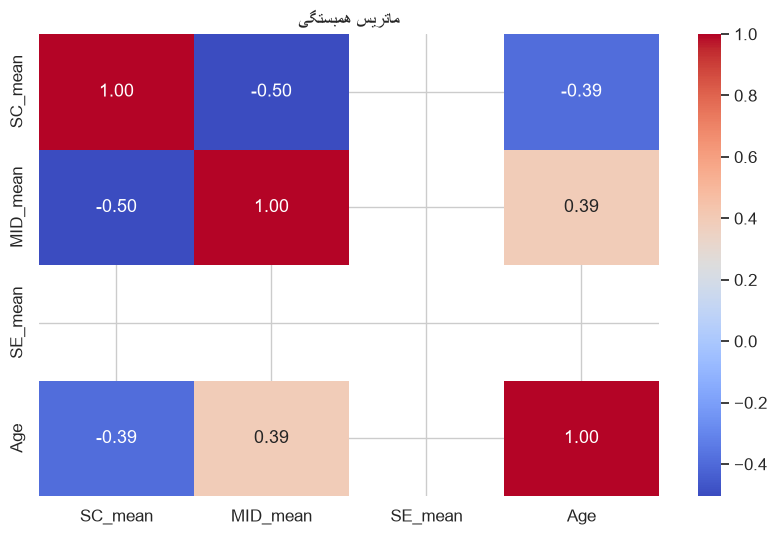

In [11]:
corr_cols = ['SC_mean', 'MID_mean', 'SE_mean', 'Age']
corr = df[corr_cols].corr(method='pearson')
print(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('ماتریس همبستگی')
plt.show()

In [ ]:
model = smf.ols(
    'SE_mean ~ SC_mean + MID_mean + C(Gender) + Age + C(Education)',
    data=df
).fit()

print(model.summary())

In [14]:
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [16]:
print(df['Education'].value_counts(dropna=False))

Education
لیسانس و فوق لیسانس    107
دیپلم و فوق دیپلم       20
دکترا و فوق دکترا        8
Name: count, dtype: int64


In [17]:
print(df.groupby('Education')['SE_mean'].apply(lambda x: x.notna().sum()))

Education
دکترا و فوق دکترا      0
دیپلم و فوق دیپلم      0
لیسانس و فوق لیسانس    0
Name: SE_mean, dtype: int64


In [18]:
print("تعداد NaN در SE_mean:", df['SE_mean'].isna().sum())
print(df[df['SE_mean'].isna()][['Gender','Age','Education']])

تعداد NaN در SE_mean: 135
    Gender   Age            Education
0       زن  22.0  لیسانس و فوق لیسانس
1       زن  21.0    دیپلم و فوق دیپلم
2       زن  19.0    دیپلم و فوق دیپلم
3       زن  35.0  لیسانس و فوق لیسانس
4       زن  32.0  لیسانس و فوق لیسانس
..     ...   ...                  ...
130    مرد  27.0  لیسانس و فوق لیسانس
131     زن  27.0  لیسانس و فوق لیسانس
132     زن  24.0  لیسانس و فوق لیسانس
133     زن  27.0  لیسانس و فوق لیسانس
134     زن  26.0  لیسانس و فوق لیسانس

[135 rows x 3 columns]


In [19]:
df_clean = df.dropna(subset=['SC_mean','MID_mean','SE_mean']).copy()
print("تعداد ردیف‌های کامل:", len(df_clean))
print(df_clean['Education'].value_counts())

تعداد ردیف‌های کامل: 0
Series([], Name: count, dtype: int64)


In [21]:
print("df_clean وجود دارد؟", 'df_clean' in dir())
if 'df_clean' in dir():
    print("ابعاد df_clean:", df_clean.shape)
    print("ستون‌ها:", df_clean.columns.tolist()[:10])
    print("تعداد NaN در SE_mean:", df_clean['SE_mean'].isna().sum())
    print("تعداد کل SE_mean غیر NaN:", df_clean['SE_mean'].notna().sum())
    print()
    print("تعداد غیر NaN در هر گروه تحصیلی:")
    print(df_clean.groupby('Education')['SE_mean'].apply(lambda x: x.notna().sum()))

df_clean وجود دارد؟ True
ابعاد df_clean: (0, 61)
ستون‌ها: ['پاسخنامه', 'شناسه پاسخ دهنده', 'Gender', 'Age', 'Education', '1.اگر برای عزیزانم یا دوستانم کاری انجام میدهم، آن را با کارهایی که دیگران انجام میدهند مقایسه میکنم.', '2. به روشی که خودم کارها را انجام می دهم نسبت به روشی که سایرین انجام می دهند، توجه زیادی دارم.', '3. عملکرد خودم \xa0را با دیگران مقایسه می کنم.', '4. معمولاً رفتارها و مهارت های اجتماعی خودم را با این قبیل مهارت ها در دیگران مقایسه می کنم.', '5. از آن دسته افرادی نیستم که خودش را با دیگران مقایسه می کند.']
تعداد NaN در SE_mean: 0
تعداد کل SE_mean غیر NaN: 0

تعداد غیر NaN در هر گروه تحصیلی:
Series([], Name: SE_mean, dtype: float64)


In [22]:
print("ابعاد df اصلی:", df.shape)
print()
print("تعداد NaN در SC_mean:", df['SC_mean'].isna().sum(), "از", len(df))
print("تعداد NaN در MID_mean:", df['MID_mean'].isna().sum(), "از", len(df))
print("تعداد NaN در SE_mean:", df['SE_mean'].isna().sum(), "از", len(df))
print()
print("چند نمونه از مقادیر SC_mean:")
print(df['SC_mean'].head(10))
print()
print("چند نمونه از مقادیر SE_mean:")
print(df['SE_mean'].head(10))

ابعاد df اصلی: (135, 61)

تعداد NaN در SC_mean: 0 از 135
تعداد NaN در MID_mean: 0 از 135
تعداد NaN در SE_mean: 135 از 135

چند نمونه از مقادیر SC_mean:
0    4.090909
1    5.818182
2    6.363636
3    3.272727
4    5.363636
5    6.090909
6    6.090909
7    6.000000
8    5.909091
9    4.545455
Name: SC_mean, dtype: float64

چند نمونه از مقادیر SE_mean:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: SE_mean, dtype: float64


In [23]:
print("sc_cols:", len(sc_cols))
print("mid_cols:", len(mid_cols))
print("se_cols:", len(se_cols))
print()
print("نمونه مقادیر ستون اول عزت نفس:")
print(df[se_cols[0]].head(10))
print()
print("dtype ستون اول عزت نفس:", df[se_cols[0]].dtype)

sc_cols: 11
mid_cols: 27
se_cols: 10

نمونه مقادیر ستون اول عزت نفس:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: 1.احساس می کنم انسان با ارزشی هستم، حداقل به اندازه دیگران., dtype: float64

dtype ستون اول عزت نفس: float64


In [24]:
# مقادیر یکتا در ستون اول عزت نفس
print(df[se_cols[0]].dropna().unique()[:20])
print()
print("تعداد NaN بعد از تبدیل:", df[se_cols[0]].isna().sum(), "از", len(df))

[]

تعداد NaN بعد از تبدیل: 135 از 135


In [25]:
likert_map = {
    'خیلی مخالفم': 1,
    'مخالفم': 2,
    'تا حدودی مخالفم': 3,
    'تاحدی مخالفم': 3,
    'تا حدی مخالفم': 3,
    'نظری ندارم': 4,
    'تا حدودی موافقم': 5,
    'تاحدی موافقم': 5,
    'تا حدی موافقم': 5,
    'موافقم': 6,
    'موافق': 6,        # ← اضافه شد
    'خیلی موافقم': 7,
    'مخالف': 2,        # ← اضافه شد
}

In [26]:
for c in sc_cols + mid_cols + se_cols:
    df[c] = df[c].apply(likert_to_num)

# چک
print("تعداد NaN در ستون اول عزت نفس:", df[se_cols[0]].isna().sum())

df['SC_mean'] = df[sc_cols].mean(axis=1)
df['MID_mean'] = df[mid_cols].mean(axis=1)
df['SE_mean'] = df[se_cols].mean(axis=1)

print("تعداد NaN در SE_mean:", df['SE_mean'].isna().sum(), "از", len(df))

تعداد NaN در ستون اول عزت نفس: 135
تعداد NaN در SE_mean: 135 از 135


In [27]:
col = se_cols[0]
print("نوع داده ستون:", df[col].dtype)
print("تعداد کل:", len(df))
print("تعداد non-null قبل از تبدیل:", df[col].notna().sum())
print()
print("مقادیر یکتا:")
vals = df[col].dropna().unique()
for v in vals[:30]:
    print(repr(v))

نوع داده ستون: float64
تعداد کل: 135
تعداد non-null قبل از تبدیل: 0

مقادیر یکتا:


In [28]:
# سلول ۱: importها
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# سلول ۲: خواندن فایل
file_path = r"C:\Users\leila.gh\Desktop\selfsteem.socialcomparison\selfsteem.xlsx"
try:
    df = pd.read_excel(file_path, sheet_name="Results")
except ValueError:
    df = pd.read_excel(file_path, sheet_name=0)

df = df.dropna(how='all')
df = df[df.iloc[:, 1].notna()].reset_index(drop=True)

# نام‌گذاری
df = df.rename(columns={
    df.columns[2]: 'Gender',
    df.columns[3]: 'Age',
    df.columns[4]: 'Education'
})

# تبدیل سن
def fa_to_en_digits(x):
    if pd.isna(x):
        return x
    return str(x).translate(str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789'))

df['Age'] = pd.to_numeric(df['Age'].apply(fa_to_en_digits), errors='coerce')
df.loc[(df['Age'] < 15) | (df['Age'] > 80), 'Age'] = np.nan

# سلول ۳: ستون‌ها
sc_cols = df.columns[5:16].tolist()
mid_cols = df.columns[16:43].tolist()
se_cols = df.columns[43:53].tolist()

# سلول ۴: نگاشت
likert_map = {
    'خیلی مخالفم': 1,
    'مخالف': 2,
    'مخالفم': 2,
    'تا حدودی مخالفم': 3,
    'تاحدی مخالفم': 3,
    'تا حدی مخالفم': 3,
    'نظری ندارم': 4,
    'تا حدودی موافقم': 5,
    'تاحدی موافقم': 5,
    'تا حدی موافقم': 5,
    'موافق': 6,
    'موافقم': 6,
    'خیلی موافقم': 7,
}

def likert_to_num(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)  # اگه از قبل عددی شده بود
    x = str(x).strip().replace('ي', 'ی').replace('ك', 'ک')
    x = ' '.join(x.split())
    return likert_map.get(x, np.nan)

# تبدیل
for c in sc_cols + mid_cols + se_cols:
    df[c] = df[c].apply(likert_to_num)

# چک
print("تعداد NaN ستون اول عزت نفس:", df[se_cols[0]].isna().sum(), "از", len(df))
print(df[se_cols[0]].value_counts().sort_index())

تعداد NaN ستون اول عزت نفس: 0 از 135
1.احساس می کنم انسان با ارزشی هستم، حداقل به اندازه دیگران.
2     17
6    118
Name: count, dtype: int64


In [29]:
for i, c in enumerate(se_cols):
    print(f"سوال {i+1}: {sorted(df[c].dropna().unique())}")

سوال 1: [np.int64(2), np.int64(6)]
سوال 2: [np.int64(2), np.int64(6)]
سوال 3: [np.int64(2), np.int64(6)]
سوال 4: [np.int64(2), np.int64(6)]
سوال 5: [np.int64(2), np.int64(6)]
سوال 6: [np.int64(2), np.int64(6)]
سوال 7: [np.int64(2), np.int64(6)]
سوال 8: [np.int64(2), np.int64(6)]
سوال 9: [np.int64(2), np.int64(6)]
سوال 10: [np.int64(2), np.int64(6)]


In [30]:
se_reverse_idx = [5, 6, 7, 8, 9]
for i in se_reverse_idx:
    df[se_cols[i]] = df[se_cols[i]].apply(reverse_7)

In [31]:
df['SC_mean'] = df[sc_cols].mean(axis=1)
df['MID_mean'] = df[mid_cols].mean(axis=1)
df['SE_mean'] = df[se_cols].mean(axis=1)

df['SE_sum'] = df[se_cols].sum(axis=1)

print("تعداد NaN در SE_mean:", df['SE_mean'].isna().sum(), "از", len(df))
print(df[['SC_mean','MID_mean','SE_mean']].describe())

تعداد NaN در SE_mean: 0 از 135
          SC_mean    MID_mean     SE_mean
count  135.000000  135.000000  135.000000
mean     4.825589    4.137174    4.554074
std      0.637144    0.760813    1.131355
min      2.363636    2.666667    2.000000
25%      4.500000    3.537037    3.600000
50%      4.909091    4.037037    4.800000
75%      5.181818    4.648148    5.600000
max      7.000000    7.000000    6.000000


In [32]:
def cronbach_alpha(items_df):
    items_df = items_df.dropna()
    k = items_df.shape[1]
    item_var = items_df.var(axis=0, ddof=1)
    total_var = items_df.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

print("آلفای کرونباخ SC:", cronbach_alpha(df[sc_cols]))
print("آلفای کرونباخ MID:", cronbach_alpha(df[mid_cols]))
print("آلفای کرونباخ SE:", cronbach_alpha(df[se_cols]))

آلفای کرونباخ SC: 0.4665614055621077
آلفای کرونباخ MID: 0.8125384113545445
آلفای کرونباخ SE: 0.8391761949074202


In [33]:
df_clean = df.dropna(subset=['SC_mean','MID_mean','SE_mean']).copy()
print("تعداد ردیف‌های کامل:", len(df_clean))

# ANOVA
groups = [g['SE_mean'].dropna().values for _, g in df_clean.groupby('Education')]
groups = [g for g in groups if len(g) >= 2]
F, p = stats.f_oneway(*groups)
print(f'ANOVA: F={F:.3f}, p={p:.4f}')

# t-test جنسیت
m = df_clean[df_clean['Gender']=='مرد']['SE_mean'].dropna()
f = df_clean[df_clean['Gender']=='زن']['SE_mean'].dropna()
t, p = stats.ttest_ind(m, f, equal_var=False)
print(f't-test: t={t:.3f}, p={p:.4f}')

# همبستگی
print(df_clean[['SC_mean','MID_mean','SE_mean','Age']].corr())

# رگرسیون
model = smf.ols('SE_mean ~ SC_mean + MID_mean + C(Gender) + Age', data=df_clean).fit()
print(model.summary())

تعداد ردیف‌های کامل: 135
ANOVA: F=0.343, p=0.7106
t-test: t=2.225, p=0.0300
           SC_mean  MID_mean   SE_mean       Age
SC_mean   1.000000  0.378461 -0.318956 -0.151143
MID_mean  0.378461  1.000000 -0.642426 -0.415181
SE_mean  -0.318956 -0.642426  1.000000  0.363832
Age      -0.151143 -0.415181  0.363832  1.000000
                            OLS Regression Results                            
Dep. Variable:                SE_mean   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     27.69
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.43e-16
Time:                        17:38:19   Log-Likelihood:                -163.23
No. Observations:                 133   AIC:                             336.5
Df Residuals:                     128   BIC:                             350.9
Df Model:                           4          

In [34]:
print(df_clean.groupby('Gender')['SE_mean'].agg(['mean','std','count']))

            mean       std  count
Gender                           
زن      4.431683  1.122402    101
مرد     4.917647  1.094468     34


In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df_clean[['SC_mean','MID_mean','Age']].dropna()
X = sm.add_constant(X)
vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)

   variable         VIF
0     const  119.691622
1   SC_mean    1.109371
2  MID_mean    1.309807
3       Age    1.209001


In [36]:
!pip install pingouin -q
import pingouin as pg
pg.mediation_analysis(data=df_clean, x='SC_mean', m='MID_mean', y='SE_mean', n_boot=5000)

,path,coef,se,pval,CI2.5,CI97.5,sig
0,MID_mean ~ X,0.451920,0.095840,6.012479e-06,0.262353,0.641488,Yes
1,Y ~ MID_mean,-0.955310,0.098815,4.524315e-17,-1.150762,-0.759859,Yes
2,Total,-0.566360,0.145928,1.629573e-04,-0.855000,-0.277721,Yes
3,Direct,-0.157145,0.127225,2.189627e-01,-0.408809,0.094520,No
4,Indirect,-0.409216,0.106254,0.000000e+00,-0.628698,-0.215156,Yes


In [37]:
print(df_clean[['SC_mean','MID_mean','SE_mean','Age']].describe().round(2))
print()
print(df_clean.groupby('Gender')[['SC_mean','MID_mean','SE_mean','Age']].mean().round(2))

       SC_mean  MID_mean  SE_mean     Age
count   135.00    135.00   135.00  133.00
mean      4.83      4.14     4.55   28.23
std       0.64      0.76     1.13    7.98
min       2.36      2.67     2.00   16.00
25%       4.50      3.54     3.60   23.00
50%       4.91      4.04     4.80   26.00
75%       5.18      4.65     5.60   31.00
max       7.00      7.00     6.00   66.00

        SC_mean  MID_mean  SE_mean    Age
Gender                                   
زن         4.86      4.20     4.43  26.24
مرد        4.71      3.95     4.92  34.00


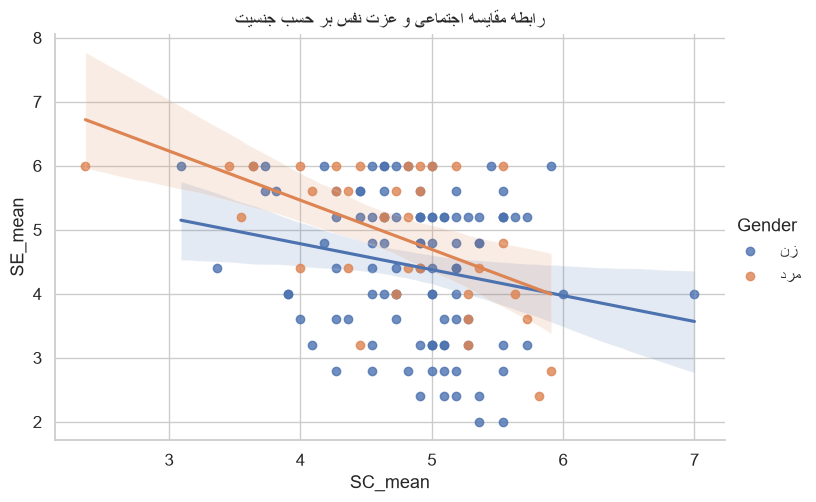

In [38]:
sns.lmplot(x='SC_mean', y='SE_mean', hue='Gender', data=df_clean, height=5, aspect=1.5)
plt.title('رابطه مقایسه اجتماعی و عزت نفس بر حسب جنسیت')
plt.show()